# 🇧🇯 Pipeline de Données — Bénin Insights Challenge
**Groupe 16 · iSHEERO × DataCamp Donates · 2025**

Ce notebook implémente le **pipeline officiel V2** en 4 étapes :
1. 📥 Extraction depuis BigQuery (requête officielle)
2. 🧹 Nettoyage & Validation
3. ✨ Enrichissement (colonnes dérivées)
4. 💾 Export dataset gold

---
> ⚠️ **Prérequis** : compte Google avec BigQuery activé (quota gratuit 1 TB/mois)

## 📦 Cellule 1 — Installation des dépendances

In [ ]:
!pip install google-cloud-bigquery google-auth pandas matplotlib seaborn plotly db-dtypes --quiet
print('✅ Installation terminée !')

## 🔑 Cellule 2 — Authentification Google BigQuery

**Comment obtenir ton fichier de clé JSON :**
1. Va sur [console.cloud.google.com](https://console.cloud.google.com)
2. Crée un projet et active l'API BigQuery
3. **IAM & Admin → Comptes de service → Créer**
4. Rôle : **BigQuery User** + **BigQuery Job User**
5. Crée une clé JSON, télécharge-la dans le même dossier que ce notebook

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('gdelt_benin_2025_raw.csv')   # ← pas de lien markdown

df['SQLDATE'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')

df_raw = df[df['SQLDATE'].dt.year == 2025].copy()

avant = len(df)
df_raw = df_raw.drop_duplicates()

print(f"Données brutes              : {len(df)} lignes")
print(f"Après filtre 2025           : {avant} lignes")
print(f"Après suppression doublons  : {len(df_raw)} lignes")
print(f"Période : {df_raw['SQLDATE'].min().date()} → {df_raw['SQLDATE'].max().date()}")
print(f"\nColonnes : {df_raw.columns.tolist()}")

Données brutes              : 23859 lignes
Après filtre 2025           : 23859 lignes
Après suppression doublons  : 23461 lignes
Période : 2025-01-01 → 2025-12-31

Colonnes : ['SQLDATE', 'EventCode', 'EventBaseCode', 'EventRootCode', 'QuadClass', 'Actor1Name', 'Actor1CountryCode', 'Actor1Type1Code', 'Actor2Name', 'Actor2CountryCode', 'Actor2Type1Code', 'ActionGeo_FullName', 'ActionGeo_Lat', 'ActionGeo_Long', 'GoldsteinScale', 'NumMentions', 'NumArticles', 'AvgTone', 'SOURCEURL']


## 📥 ÉTAPE 1 — Extraction depuis BigQuery

**Requête officielle V2** — Filtre `YEAR = 2025` en premier pour préserver le quota gratuit (1 TB/mois). Le filtre strict sur `SQLDATE` sera appliqué en post-traitement Python.

### Colonnes retenues et justification
| Colonne | Rôle |
|---|---|
| `SQLDATE` | Axe temporel principal (YYYYMMDD) |
| `EventCode` / `EventBaseCode` / `EventRootCode` | Hiérarchie CAMEO (granularité maximale → ML) |
| `QuadClass` | 4 familles lisibles (Coopération/Conflit verbale/matérielle) |
| `Actor1/2Name` | Acteurs impliqués |
| `Actor1/2CountryCode` | Nationalité des acteurs |
| `Actor1/2Type1Code` | Nature de l'acteur (GOV, MIL, REB, NGO…) |
| `ActionGeo_FullName` | Lieu lisible (dashboard/rapports) |
| `ActionGeo_Lat/Long` | Coordonnées GPS (carte + filtre Benin City) |
| `GoldsteinScale` | Stabilité théorique (-10 → +10) |
| `NumMentions` | Importance perçue de l'événement |
| `NumArticles` | Poids médiatique (proxy le plus fiable) |
| `AvgTone` | Ton médiatique moyen |
| `SOURCEURL` | Vérification manuelle + extraction domaine/langue |

In [12]:
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# REQUÊTE OFFICIELLE V2 — Pipeline Groupe 16
# YEAR = 2025 filtre en BigQuery pour économiser le quota (1 TB/mois gratuit)
# Le filtre strict sur SQLDATE sera appliqué en Python (étape 2.1)
# ─────────────────────────────────────────────────────────────────────────────
query = """
SELECT
  -- Identification temporelle
  SQLDATE,

  -- Hiérarchie des événements (3 niveaux CAMEO)
  EventCode,
  EventBaseCode,
  EventRootCode,
  QuadClass,

  -- Acteurs
  Actor1Name,
  Actor1CountryCode,
  Actor1Type1Code,
  Actor2Name,
  Actor2CountryCode,
  Actor2Type1Code,

  -- Géographie de l'action
  ActionGeo_FullName,
  ActionGeo_Lat,
  ActionGeo_Long,

  -- Indicateurs d'impact
  GoldsteinScale,
  NumMentions,
  NumArticles,
  AvgTone,

  -- Source et langue
  SOURCEURL

FROM `gdelt-bq.gdeltv2.events`
WHERE ActionGeo_CountryCode = 'BN'
  AND YEAR = 2025
"""

print(f'✅ {len(df_raw):,} lignes disponibles')
print(f'📅 Années détectées : {df_raw["SQLDATE"].astype(str).str[:4].value_counts().to_dict()}')
df_raw.head(3)

✅ 23,461 lignes disponibles
📅 Années détectées : {'2025': 23461}


,SQLDATE,EventCode,EventBaseCode,EventRootCode,QuadClass,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Name,Actor2CountryCode,Actor2Type1Code,ActionGeo_FullName,ActionGeo_Lat,ActionGeo_Long,GoldsteinScale,NumMentions,NumArticles,AvgTone,SOURCEURL
0,2025-12-31,1712,171,17,4,OPERATIVE,NaN,SPY,NaN,NaN,NaN,Benin,9.5,2.25,-9.2,10,10,-9.577465,https://dailypost.ng/2025/12/31/nscdc-arrests-...
1,2025-02-09,16,16,1,1,CONGRESS,NaN,LEG,DEMOCRATIC PARTY,NaN,NaN,Benin,9.5,2.25,-2.0,10,10,-5.177994,https://thesun.ng/apc-dismisses-pdps-claims-on...
2,2025-02-09,1712,171,17,4,BENIN,BEN,NaN,BENIN CITY,NGA,NaN,Benin,9.5,2.25,-9.2,4,4,-5.309735,https://dailypost.ng/2025/02/09/police-rescue-...


## 🧹 ÉTAPE 2 — Nettoyage & Validation

4 sous-étapes dans l'ordre :
1. **Filtrage temporel strict** — SQLDATE ∈ [2025-01-01, 2025-12-31]
2. **Suppression des doublons stricts** (~2.2% détectés en EDA)
3. **Filtrage géographique** — Exclusion de Benin City (Nigeria)
4. **Gestion des valeurs manquantes** — Stratégie colonne par colonne

In [18]:
import numpy as np

df = df_raw.copy()

# ─────────────────────────────────────────────────────────────────────────────
# 2.1 FILTRAGE TEMPOREL STRICT
# BigQuery filtre sur YEAR (année de détection) ≠ année réelle de l'événement.
# Double sécurité : filtre YEAR=2025 en SQL + filtre SQLDATE en Python.
# Sans ce filtre Python, les données vont jusqu'en avril 2026 (confirmé EDA).
# ─────────────────────────────────────────────────────────────────────────────
df['date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d', errors='coerce')
print(df)
avant = len(df)
df = df[(df['SQLDATE'] >= '2025-01-01') & (df['SQLDATE'] <= '2025-12-31')]
print(f'📅 Filtrage temporel strict : {avant:,} → {len(df):,} lignes '
      f'({avant - len(df):,} lignes hors 2025 supprimées)')
df.head(5)

         SQLDATE  EventCode  EventBaseCode  EventRootCode  QuadClass  \
0     2025-12-31       1712            171             17          4   
1     2025-02-09         16             16              1          1   
2     2025-02-09       1712            171             17          4   
3     2025-03-04         22             22              2          1   
4     2025-01-01         16             16              1          1   
...          ...        ...            ...            ...        ...   
23854 2025-01-16        193            193             19          4   
23855 2025-01-16        193            193             19          4   
23856 2025-01-16        193            193             19          4   
23857 2025-01-16        193            193             19          4   
23858 2025-01-16        193            193             19          4   

      Actor1Name Actor1CountryCode Actor1Type1Code        Actor2Name  \
0      OPERATIVE               NaN             SPY             

,SQLDATE,EventCode,EventBaseCode,EventRootCode,QuadClass,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Name,Actor2CountryCode,Actor2Type1Code,ActionGeo_FullName,ActionGeo_Lat,ActionGeo_Long,GoldsteinScale,NumMentions,NumArticles,AvgTone,SOURCEURL,date
0,2025-12-31,1712,171,17,4,OPERATIVE,NaN,SPY,NaN,NaN,NaN,Benin,9.5,2.25,-9.2,10,10,-9.577465,https://dailypost.ng/2025/12/31/nscdc-arrests-...,NaT
1,2025-02-09,16,16,1,1,CONGRESS,NaN,LEG,DEMOCRATIC PARTY,NaN,NaN,Benin,9.5,2.25,-2.0,10,10,-5.177994,https://thesun.ng/apc-dismisses-pdps-claims-on...,NaT
2,2025-02-09,1712,171,17,4,BENIN,BEN,NaN,BENIN CITY,NGA,NaN,Benin,9.5,2.25,-9.2,4,4,-5.309735,https://dailypost.ng/2025/02/09/police-rescue-...,NaT
3,2025-03-04,22,22,2,1,PRISONER,NaN,OPP,NaN,NaN,NaN,Benin,9.5,2.25,3.2,10,10,-2.621723,https://lanouvelletribune.info/2026/03/benin-d...,NaT
4,2025-01-01,16,16,1,1,GOVERNOR,NaN,GOV,NaN,NaN,NaN,Benin,9.5,2.25,-2.0,3,3,-12.206573,https://punchng.com/pdp-seeks-igs-intervention...,NaT


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.2 SUPPRESSION DES DOUBLONS STRICTS
# Cause : un même article peut être traité plusieurs fois par le pipeline GDELT
# sur la même fenêtre de 15 minutes.
# Ce qu'on NE fait PAS : les doublons sémantiques (même événement, sources
# différentes) sont CONSERVÉS — c'est voulu par GDELT, NumArticles le capture.
# ─────────────────────────────────────────────────────────────────────────────
avant = len(df)
cols_dedup = [c for c in df.columns if c != 'date']  # exclure colonne dérivée
df = df.drop_duplicates(subset=cols_dedup)
print(f'🔄 Suppression doublons stricts : {avant:,} → {len(df):,} '
      f'({avant - len(df):,} doublons supprimés, '
      f'{(avant - len(df))/avant*100:.1f}%)')

🔄 Suppression doublons stricts : 23,461 → 23,461 (0 doublons supprimés, 0.0%)


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.3 FILTRAGE GÉOGRAPHIQUE — EXCLUSION DE BENIN CITY (NIGERIA)
#
# Problème : GDELT confond le Bénin-pays avec Benin City (État d'Edo, Nigeria).
# Biais confirmé EDA : acteur 'BENIN CITY', URLs nigérianes (punchng.com,
# dailypost.ng) dans des événements tagués BN.
#
# Boîte géographique du Bénin-pays :
#   Latitude  : 6.1°N → 12.4°N
#   Longitude : 0.8°E → 3.8°E
#
# Benin City Nigeria : 6.3°N, 5.6°E → HORS de notre boîte (longitude > 3.8°E)
# Centroïde générique Bénin : 9.5°N, 2.25°E → DANS la boîte (conservé)
#
# Stratégie : on filtre UNIQUEMENT les événements avec coordonnées valides
# qui tombent HORS de la boîte. Les événements sans coordonnées sont conservés.
# ─────────────────────────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = 6.1, 12.4
LON_MIN, LON_MAX = 0.8, 3.8

avant = len(df)

# Créer masque : NaN OU dans la boîte → conserver
masque_conserver = (
    df['ActionGeo_Lat'].isna() | df['ActionGeo_Long'].isna() |
    (
        (df['ActionGeo_Lat'].between(LAT_MIN, LAT_MAX)) &
        (df['ActionGeo_Long'].between(LON_MIN, LON_MAX))
    )
)

df = df[masque_conserver]
print(f'🗺️  Filtrage géographique anti-Benin City : {avant:,} → {len(df):,} '
      f'({avant - len(df):,} événements nigérians écartés)')

🗺️  Filtrage géographique anti-Benin City : 23,461 → 23,458 (3 événements nigérians écartés)


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.4 GESTION DES VALEURS MANQUANTES — Stratégie colonne par colonne
#
# RÈGLE : on ne supprime AUCUNE ligne pour cause de valeurs manquantes.
#
# Actor1/2Name → 'Non identifié'      : uniformisation de l'affichage
# Actor1/2Type1Code → 'Non identifié' : uniformisation (décision équipe)
# Actor1/2CountryCode → NaN conservé  : manquant INFORMATIF (acteur sans
#                                        nationalité claire = info en soi)
# ActionGeo_Lat/Long → NaN conservé   : traités séparément lors du filtrage géo
# ─────────────────────────────────────────────────────────────────────────────

# Afficher les taux de manquants AVANT traitement
cols_acteurs = ['Actor1Name', 'Actor1CountryCode', 'Actor1Type1Code',
                'Actor2Name', 'Actor2CountryCode', 'Actor2Type1Code',
                'ActionGeo_Lat', 'ActionGeo_Long']
missing_avant = (df[cols_acteurs].isna().sum() / len(df) * 100).round(1)
print('❓ Taux de valeurs manquantes avant traitement :')
print(missing_avant.to_string)

# Remplacement par 'Non identifié' pour les colonnes textuelles
cols_non_identifie = ['Actor1Name', 'Actor2Name', 'Actor1Type1Code', 'Actor2Type1Code']
for col in cols_non_identifie:
    if col in df.columns:
        df[col] = df[col].fillna('Non identifié')

# Les CountryCode et coordonnées GPS → NaN conservés
print('\n✅ Valeurs manquantes traitées :')
print(f'   Actor1/2Name + Type1Code → "Non identifié"')
print(f'   Actor1/2CountryCode + Coordonnées → NaN conservés (manquants informatifs)')

❓ Taux de valeurs manquantes avant traitement :
<bound method Series.to_string of Actor1Name            0.0
Actor1CountryCode    49.2
Actor1Type1Code       0.0
Actor2Name            0.0
Actor2CountryCode    58.4
Actor2Type1Code       0.0
ActionGeo_Lat         0.0
ActionGeo_Long        0.0
dtype: float64>

✅ Valeurs manquantes traitées :
   Actor1/2Name + Type1Code → "Non identifié"
   Actor1/2CountryCode + Coordonnées → NaN conservés (manquants informatifs)


In [24]:
# Bilan nettoyage
print('='*55)
print(f'📊 BILAN NETTOYAGE')
print('='*55)
print(f'  Lignes brutes BigQuery  : {len(df_raw):,}')
print(f'  Lignes après nettoyage  : {len(df):,}')
print(f'  Lignes supprimées       : {len(df_raw) - len(df):,} ({(len(df_raw)-len(df))/len(df_raw)*100:.1f}%)')
print(f'  Période couverte        : {df["date"].min().date()} → {df["date"].max().date()}')
print('='*55)

📊 BILAN NETTOYAGE
  Lignes brutes BigQuery  : 23,461
  Lignes après nettoyage  : 23,458
  Lignes supprimées       : 3 (0.0%)
  Période couverte        : NaT → NaT


In [ ]:
df_raw["date"]

## ✨ ÉTAPE 3 — Enrichissement

Création de 7 colonnes dérivées. Aucune ligne n'est supprimée à cette étape.

| Colonne | Description |
|---|---|
| `mois` | Période mensuelle (YYYY-MM) pour agrégations |
| `zone_geo` | Nord / Sud / Non localisé (3 catégories) |
| `type_quadclass` | Libellé lisible de QuadClass |
| `is_violent` | Booléen — EventRootCode ≥ 13 |
| `impact_pondere` | GoldsteinScale × log(NumArticles + 1) |
| `communaute_linguistique` | Francophonie / Anglophone / Chine / Autre |
| `source_domain` | Domaine extrait de SOURCEURL |

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.1 COLONNES TEMPORELLES
# ─────────────────────────────────────────────────────────────────────────────
df['mois'] = df['date'].dt.strftime('%Y-%m')
df['mois_nom'] = df['date'].dt.strftime('%b %Y')
print('✅ 3.1 Colonnes temporelles créées : mois, mois_nom')

✅ 3.1 Colonnes temporelles créées : mois, mois_nom


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.2 ZONE GÉOGRAPHIQUE (3 catégories — reformulée suite discussion équipe)
#
# Problème : 91% des événements ont le centroïde générique (9.5°N, 2.25°E).
# Ce centroïde tombe exactement à la frontière nord/sud (seuil 10°N).
# Solution : 3 catégories avec 'Non localisé' pour les centroïdes génériques.
#
# Distribution attendue :
#   Non localisé : ~91% (centroïde ou coordonnées manquantes)
#   Nord         : ~5%  (Atakora, Alibori — événements sécuritaires)
#   Sud          : ~4%  (Cotonou, Littoral, etc.)
# ─────────────────────────────────────────────────────────────────────────────
CENTROIDE_LAT, CENTROIDE_LON = 9.5, 2.25
TOLERANCE = 0.1  # marge pour les arrondis GDELT

def zone_geo(row):
    lat = row['ActionGeo_Lat']
    lon = row['ActionGeo_Long']
    if pd.isna(lat) or pd.isna(lon):
        return 'Non localisé'
    # Centroïde générique → Non localisé
    if abs(lat - CENTROIDE_LAT) < TOLERANCE and abs(lon - CENTROIDE_LON) < TOLERANCE:
        return 'Non localisé'
    elif lat >= 10.0:
        return 'Nord (Atakora / Alibori)'
    else:
        return 'Sud'

df['zone_geo'] = df.apply(zone_geo, axis=1)

print('✅ 3.2 zone_geo créée')
print(df['zone_geo'].value_counts(normalize=True).mul(100).round(1).to_string())

✅ 3.2 zone_geo créée
zone_geo
Non localisé                91.3
Sud                          6.0
Nord (Atakora / Alibori)     2.7


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.3 TYPE D'ÉVÉNEMENT LISIBLE (libellé QuadClass)
# ─────────────────────────────────────────────────────────────────────────────
quadclass_labels = {
    1: 'Coopération verbale',
    2: 'Coopération matérielle',
    3: 'Conflit verbal',
    4: 'Conflit matériel'
}
df['type_quadclass'] = df['QuadClass'].map(quadclass_labels).fillna('Non classifié')
print('✅ 3.3 type_quadclass créée')
print(df['type_quadclass'].value_counts().to_string())

✅ 3.3 type_quadclass créée
type_quadclass
Coopération verbale       14943
Conflit matériel           3305
Conflit verbal             2852
Coopération matérielle     2358


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.4 INDICATEUR BOOLÉEN DE VIOLENCE
# EventRootCode >= 13 = codes conflictuels selon taxonomie CAMEO
# (codes 01-12 = coopération, 13-20 = conflit/force)
# ─────────────────────────────────────────────────────────────────────────────
df['is_violent'] = df['EventRootCode'].apply(
    lambda x: True if pd.notna(x) and int(str(x)[:2]) >= 13 else False
)
pct_violent = df['is_violent'].mean() * 100
print(f'✅ 3.4 is_violent créée')
print(f'   {pct_violent:.1f}% des événements sont violents (EventRootCode ≥ 13)')

✅ 3.4 is_violent créée
   17.1% des événements sont violents (EventRootCode ≥ 13)


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.5 SCORE D'IMPACT PONDÉRÉ
#
# Formule : impact_pondere = GoldsteinScale × log(NumArticles + 1)
#
# Problème résolu : GoldsteinScale est assigné par TYPE d'événement, pas par
# événement individuel. Une attaque terroriste (50 morts) et une altercation
# mineure du même code CAMEO reçoivent le même score Goldstein.
# Ce qui les différencie dans GDELT : NumArticles (poids médiatique).
#
# Le log() atténue l'amplification excessive — 48 articles ≠ 48× plus important.
#
# Exemple concret :
#   Attaque nord (grave)  : Goldstein=-10, NumArticles=30 → impact=-34.0
#   Incident mineur       : Goldstein=-10, NumArticles=1  → impact=-6.9
#   Accord diplomatique   : Goldstein=+3.4, NumArticles=48 → impact=+13.1
# ─────────────────────────────────────────────────────────────────────────────
df['impact_pondere'] = df['GoldsteinScale'] * np.log(df['NumArticles'].fillna(0) + 1)

print('✅ 3.5 impact_pondere créée')
print(f'   Min   : {df["impact_pondere"].min():.2f}')
print(f'   Max   : {df["impact_pondere"].max():.2f}')
print(f'   Moyen : {df["impact_pondere"].mean():.2f}')

✅ 3.5 impact_pondere créée
   Min   : -34.34
   Max   : 26.00
   Moyen : 0.96


In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.6 COMMUNAUTÉ LINGUISTIQUE DE COUVERTURE (Phase 1 — approximation par domaine)
#
# Répond à : "La presse francophone couvre-t-elle le Bénin différemment ?"
#
# Phase 1 (EDA & dashboard) : extraction depuis le domaine de SOURCEURL
# Phase 2 (pipeline officiel) : jointure table Mentions → MentionDocTranslationInfo
#                               (srclc:fra = français, srclc:ara = arabe, etc.)
# ─────────────────────────────────────────────────────────────────────────────
def detecter_communaute(url):
    if pd.isna(url):
        return 'Autre / Non identifié'
    url = str(url).lower()
    if any(x in url for x in ['.fr/', 'allafrica.com/french', '/fr/', 'rfi.fr',
                                'lemonde.fr', 'lefigaro.fr', 'afrique.le360.ma',
                                'beninwebtv', 'fraternite', 'actu.fr', '24haubenin',
                                'benin.24haubenin', 'banouto.bj', 'golfeinfo.bj']):
        return 'Francophonie'
    elif any(x in url for x in ['.ng/', '.gh/', '.ke/', '.za/', 'bbc.com',
                                  'reuters.com', 'allafrica.com/stories',
                                  'punchng.com', 'dailypost.ng', 'vanguardngr.com',
                                  'apnews.com', 'bloomberg.com', '.co.uk/']):
        return 'Commonwealth / Anglophone'
    elif any(x in url for x in ['.cn/', 'xinhua.net', 'chinadaily.com',
                                  'cgtn.com', 'global.chinadaily']):
        return 'Chine'
    elif any(x in url for x in ['.pt/', '.ao/', '.br/', 'brasil', 'angola',
                                  'lusofonia', 'voaportugues']):
        return 'Lusophonie'
    else:
        return 'Autre / Non identifié'

df['communaute_linguistique'] = df['SOURCEURL'].apply(detecter_communaute)

print('✅ 3.6 communaute_linguistique créée')
print(df['communaute_linguistique'].value_counts().to_string())
print(df_raw["SOURCEURL"])

✅ 3.6 communaute_linguistique créée
communaute_linguistique
Autre / Non identifié        14394
Commonwealth / Anglophone     8333
Francophonie                   396
Chine                          203
Lusophonie                     135
0        https://dailypost.ng/2025/12/31/nscdc-arrests-...
1        https://thesun.ng/apc-dismisses-pdps-claims-on...
2        https://dailypost.ng/2025/02/09/police-rescue-...
3        https://lanouvelletribune.info/2026/03/benin-d...
4        https://punchng.com/pdp-seeks-igs-intervention...
                               ...                        
23854    https://dailypost.ng/2025/01/16/edo-police-com...
23855    https://leadership.ng/apc-pdp-trade-words-over...
23856    https://leadership.ng/apc-pdp-trade-words-over...
23857    https://blueprint.ng/apc-decries-shooting-at-e...
23858    https://www.peoplesdailyng.com/apc-pdp-trade-t...
Name: SOURCEURL, Length: 23461, dtype: object


In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.7 LANGUE DE COUVERTURE (plus granulaire que communaute_linguistique)
# ─────────────────────────────────────────────────────────────────────────────
def detecter_langue(url):
    if pd.isna(url):
        return 'Indéterminée'
    url = str(url).lower()

    # ── Français ────────────────────────────────────────────────
    if any(x in url for x in [
        '.fr/', '/fr/', 'rfi.fr', 'lemonde.fr', 'lefigaro.fr',
        'allafrica.com/french', 'afrique.le360.ma', 'beninwebtv',
        'banouto.bj', 'golfeinfo.bj', '24haubenin', 'fraternite',
        'actu.fr', 'lanouvelletribune', 'beninprime', 'matinlibre',
        'lequotidien', 'lepatriote', 'matin-libre', 'lejour.bj',
        'benin-actu', 'latribune.bj', 'lerenouveaubj'
    ]):
        return 'Français'

    # ── Anglais ─────────────────────────────────────────────────
    elif any(x in url for x in [
        '.ng/', '.gh/', '.ke/', '.za/', '.ug/', '.rw/', '.et/',
        'bbc.com', 'reuters.com', 'apnews.com', 'bloomberg.com',
        'allafrica.com/stories', 'punchng.com', 'dailypost.ng',
        'vanguardngr.com', 'thesun.ng', 'guardian.ng',
        'premiumtimesng.com', 'channelstv.com', 'thisdaylive.com',
        '.co.uk/', 'theafricareport.com', 'africanews.com'
    ]):
        return 'Anglais'

    # ── Chinois (mandarin) ───────────────────────────────────────
    elif any(x in url for x in [
        '.cn/', 'xinhua.net', 'chinadaily.com',
        'cgtn.com', 'global.chinadaily', 'people.com.cn'
    ]):
        return 'Chinois'

    # ── Portugais ───────────────────────────────────────────────
    elif any(x in url for x in [
        '.pt/', '.ao/', '.br/', 'brasil', 'angola',
        'lusofonia', 'voaportugues', 'dw.com/pt'
    ]):
        return 'Portugais'

    # ── Arabe ───────────────────────────────────────────────────
    elif any(x in url for x in [
        '.ar/', 'aljazeera.net', 'arabic.', '/ar/',
        'alarabiya', 'bbc.com/arabic', 'dw.com/ar'
    ]):
        return 'Arabe'

    # ── Espagnol ────────────────────────────────────────────────
    elif any(x in url for x in [
        '.es/', '/es/', 'dw.com/es', 'bbc.com/mundo',
        'voanoticias', 'france24.com/es'
    ]):
        return 'Espagnol'

    else:
        return 'Indéterminée'

df['langue'] = df['SOURCEURL'].apply(detecter_langue)

print('✅ 3.7 langue créée')
print(df['langue'].value_counts().to_string())

# ── Ton moyen par langue ────────────────────────────────────────
print('\n📊 Ton médiatique moyen par langue :')
ton_langue = df.groupby('langue')['AvgTone'].mean().round(2).sort_values()
for lang, ton in ton_langue.items():
    emoji = '🔴' if ton < -2 else '🟡' if ton < 0 else '🟢'
    print(f'   {emoji} {lang:<20} : {ton:+.2f}')


print(df['langue'])

✅ 3.7 langue créée
langue
Indéterminée    12296
Anglais          9477
Français         1242
Chinois           203
Portugais         138
Espagnol           78
Arabe              27

📊 Ton médiatique moyen par langue :
   🔴 Arabe                : -3.04
   🔴 Anglais              : -2.03
   🟡 Indéterminée         : -1.18
   🟡 Français             : -1.15
   🟡 Espagnol             : -0.94
   🟡 Portugais            : -0.08
   🟢 Chinois              : +0.52
0             Anglais
1             Anglais
2             Anglais
3            Français
4             Anglais
             ...     
23854         Anglais
23855         Anglais
23856         Anglais
23857         Anglais
23858    Indéterminée
Name: langue, Length: 23461, dtype: object


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.7 EXTRACTION DU DOMAINE SOURCE
# Permet d'identifier les médias dominants et les sources suspectes (faux positifs)
# ─────────────────────────────────────────────────────────────────────────────
df['source_domain'] = df['SOURCEURL'].str.extract(
    r'https?://(?:www\.)?([^/]+)', expand=False
)

print('✅ 3.7 source_domain créée')
print('\nTop 10 des domaines sources :')
print(df['source_domain'].value_counts().head(10).to_string())

✅ 3.7 source_domain créée

Top 10 des domaines sources :
source_domain
dailypost.ng                1561
punchng.com                 1463
nigerianobservernews.com     982
lanouvelletribune.info       812
leadership.ng                739
guardian.ng                  671
allafrica.com                640
thesun.ng                    516
saharareporters.com          511
blueprint.ng                 488


In [32]:
# Labels CAMEO lisibles (pour visualisations)
cameo_labels = {
    1: 'Déclarations publiques',
    2: 'Appels / demandes',
    3: 'Expressions d intention',
    4: 'Consultations',
    5: 'Engagement diplomatique',
    6: 'Coopération matérielle',
    7: 'Aide fournie',
    8: 'Céder / coopérer',
    9: 'Médiation',
    10: 'Demandes / propositions',
    11: 'Désapprobation',
    12: 'Rejet',
    13: 'Menace',
    14: 'Protestation',
    15: 'Coercition',
    16: 'Attaque militaire',
    17: 'Violence non militaire',
    18: 'Assaut',
    19: 'Violence de masse',
    20: 'Usage de la force'
}
df['EventRootCode_int'] = pd.to_numeric(df['EventRootCode'].astype(str).str[:2], errors='coerce')
df['categorie_event'] = df['EventRootCode_int'].map(cameo_labels).fillna('Autre')

# Ton médiatique classifié
df['ton_label'] = pd.cut(
    df['AvgTone'],
    bins=[-100, -5, -1, 1, 5, 100],
    labels=['Très négatif', 'Négatif', 'Neutre', 'Positif', 'Très positif']
)

print('✅ Colonnes supplémentaires créées : categorie_event, ton_label')

✅ Colonnes supplémentaires créées : categorie_event, ton_label


## 💾 ÉTAPE 4 — Export Dataset Gold

Deux fichiers de sortie dans `data/processed/` :
- **`benin_2025_clean.csv`** — Dataset complet (toutes colonnes originales + dérivées)
- **`benin_2025_agregat_mensuel.csv`** — Agrégat mensuel pour le dashboard (performances optimales)

In [33]:
import os

os.makedirs('data/processed', exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# 4.1 DATASET COMPLET PROPRE (fichier de référence du projet)
# ─────────────────────────────────────────────────────────────────────────────
df.to_csv('data/processed/benin_2025_clean.csv', index=False)
print(f'✅ benin_2025_clean.csv exporté : {len(df):,} lignes × {len(df.columns)} colonnes')
print(f'   Colonnes : {list(df.columns)}')

✅ benin_2025_clean.csv exporté : 23,458 lignes × 31 colonnes
   Colonnes : ['SQLDATE', 'EventCode', 'EventBaseCode', 'EventRootCode', 'QuadClass', 'Actor1Name', 'Actor1CountryCode', 'Actor1Type1Code', 'Actor2Name', 'Actor2CountryCode', 'Actor2Type1Code', 'ActionGeo_FullName', 'ActionGeo_Lat', 'ActionGeo_Long', 'GoldsteinScale', 'NumMentions', 'NumArticles', 'AvgTone', 'SOURCEURL', 'date', 'mois', 'mois_nom', 'zone_geo', 'type_quadclass', 'is_violent', 'impact_pondere', 'communaute_linguistique', 'source_domain', 'EventRootCode_int', 'categorie_event', 'ton_label']


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.2 AGRÉGAT MENSUEL (utilisé directement par le dashboard — performances optimales)
# Granularité : mois × zone_geo × type_quadclass
# ─────────────────────────────────────────────────────────────────────────────
agregat = df.groupby(['mois', 'zone_geo', 'type_quadclass'], dropna=False).agg(
    nb_evenements    = ('SQLDATE', 'count'),
    goldstein_moyen  = ('GoldsteinScale', 'mean'),
    ton_moyen        = ('AvgTone', 'mean'),
    pct_violent      = ('is_violent', 'mean'),
    impact_pondere_moyen = ('impact_pondere', 'mean'),
    nb_articles_total = ('NumArticles', 'sum'),
    nb_mentions_total = ('NumMentions', 'sum')
).reset_index()

# Arrondir les métriques
for col in ['goldstein_moyen', 'ton_moyen', 'pct_violent', 'impact_pondere_moyen']:
    agregat[col] = agregat[col].round(3)

agregat['pct_violent'] = (agregat['pct_violent'] * 100).round(1)  # en %

agregat.to_csv('data/processed/benin_2025_agregat_mensuel.csv', index=False)
print(f'✅ benin_2025_agregat_mensuel.csv exporté : {len(agregat):,} lignes')
print(f'   Période : {agregat["mois"].min()} → {agregat["mois"].max()}')
agregat.head(10)

✅ benin_2025_agregat_mensuel.csv exporté : 12 lignes
   Période : nan → nan


,mois,zone_geo,type_quadclass,nb_evenements,goldstein_moyen,ton_moyen,pct_violent,impact_pondere_moyen,nb_articles_total,nb_mentions_total
0,NaN,Non localisé,Conflit matériel,2926,-7.700,-5.248,100.0,-13.604,17029,17456
1,NaN,Non localisé,Conflit verbal,2659,-3.625,-2.974,25.2,-6.410,15506,15708
2,NaN,Non localisé,Coopération matérielle,2153,5.306,-1.404,0.0,9.502,13072,13294
3,NaN,Non localisé,Coopération verbale,13668,2.414,-0.369,0.0,4.249,79806,81374
4,NaN,Nord (Atakora / Alibori),Conflit matériel,235,-8.596,-7.027,100.0,-15.259,1373,1431
5,NaN,Nord (Atakora / Alibori),Conflit verbal,76,-3.484,-6.453,27.6,-6.013,446,446
6,NaN,Nord (Atakora / Alibori),Coopération matérielle,65,6.377,-4.467,0.0,11.428,409,409
7,NaN,Nord (Atakora / Alibori),Coopération verbale,260,2.178,-3.525,0.0,4.162,1613,1647
8,NaN,Sud,Conflit matériel,144,-7.684,-4.633,100.0,-13.584,845,845
9,NaN,Sud,Conflit verbal,117,-3.656,-2.319,22.2,-6.434,723,723


In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# BILAN FINAL DU PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
print('='*60)
print('🏆 PIPELINE V2 — BILAN COMPLET')
print('='*60)
print(f'\n📥 EXTRACTION')
print(f'   Lignes brutes BigQuery     : {len(df_raw):,}')
print(f'\n🧹 NETTOYAGE')
print(f'   Lignes après nettoyage     : {len(df):,}')
print(f'   Supprimées (total)         : {len(df_raw) - len(df):,}')
print(f'\n✨ ENRICHISSEMENT — Colonnes dérivées créées :')
colonnes_derivees = ['mois', 'zone_geo', 'type_quadclass', 'is_violent',
                     'impact_pondere', 'communaute_linguistique', 'source_domain',
                     'categorie_event', 'ton_label']
for col in colonnes_derivees:
    print(f'   ✓ {col}')
print(f'\n💾 FICHIERS DE SORTIE')
print(f'   ✓ data/processed/benin_2025_clean.csv')
print(f'   ✓ data/processed/benin_2025_agregat_mensuel.csv')
print(f'\n📊 STATISTIQUES CLÉS')
print(f'   Période couverte           : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'   Goldstein moyen            : {df["GoldsteinScale"].mean():.2f}')
print(f'   Ton médiatique moyen       : {df["AvgTone"].mean():.2f}')
print(f'   % événements violents      : {df["is_violent"].mean()*100:.1f}%')
print(f'   Top zone conflictuelle     : {df[df["is_violent"]]["zone_geo"].value_counts().index[0]}')
print('='*60)

🏆 PIPELINE V2 — BILAN COMPLET

📥 EXTRACTION
   Lignes brutes BigQuery     : 23,461

🧹 NETTOYAGE
   Lignes après nettoyage     : 23,458
   Supprimées (total)         : 3

✨ ENRICHISSEMENT — Colonnes dérivées créées :
   ✓ mois
   ✓ zone_geo
   ✓ type_quadclass
   ✓ is_violent
   ✓ impact_pondere
   ✓ communaute_linguistique
   ✓ source_domain
   ✓ categorie_event
   ✓ ton_label

💾 FICHIERS DE SORTIE
   ✓ data/processed/benin_2025_clean.csv
   ✓ data/processed/benin_2025_agregat_mensuel.csv

📊 STATISTIQUES CLÉS
   Période couverte           : NaT → NaT
   Goldstein moyen            : 0.55
   Ton médiatique moyen       : -1.50
   % événements violents      : 17.1%
   Top zone conflictuelle     : Non localisé


---
## 📊 BONUS — Visualisations EDA

Reproductions et améliorations des visualisations initiales, maintenant alimentées par le dataset gold propre.

✅ 23,461 lignes chargées
   Période : 2025-01-01 00:00:00 → 2025-12-31 00:00:00
   Après nettoyage : 23,461 lignes 2025


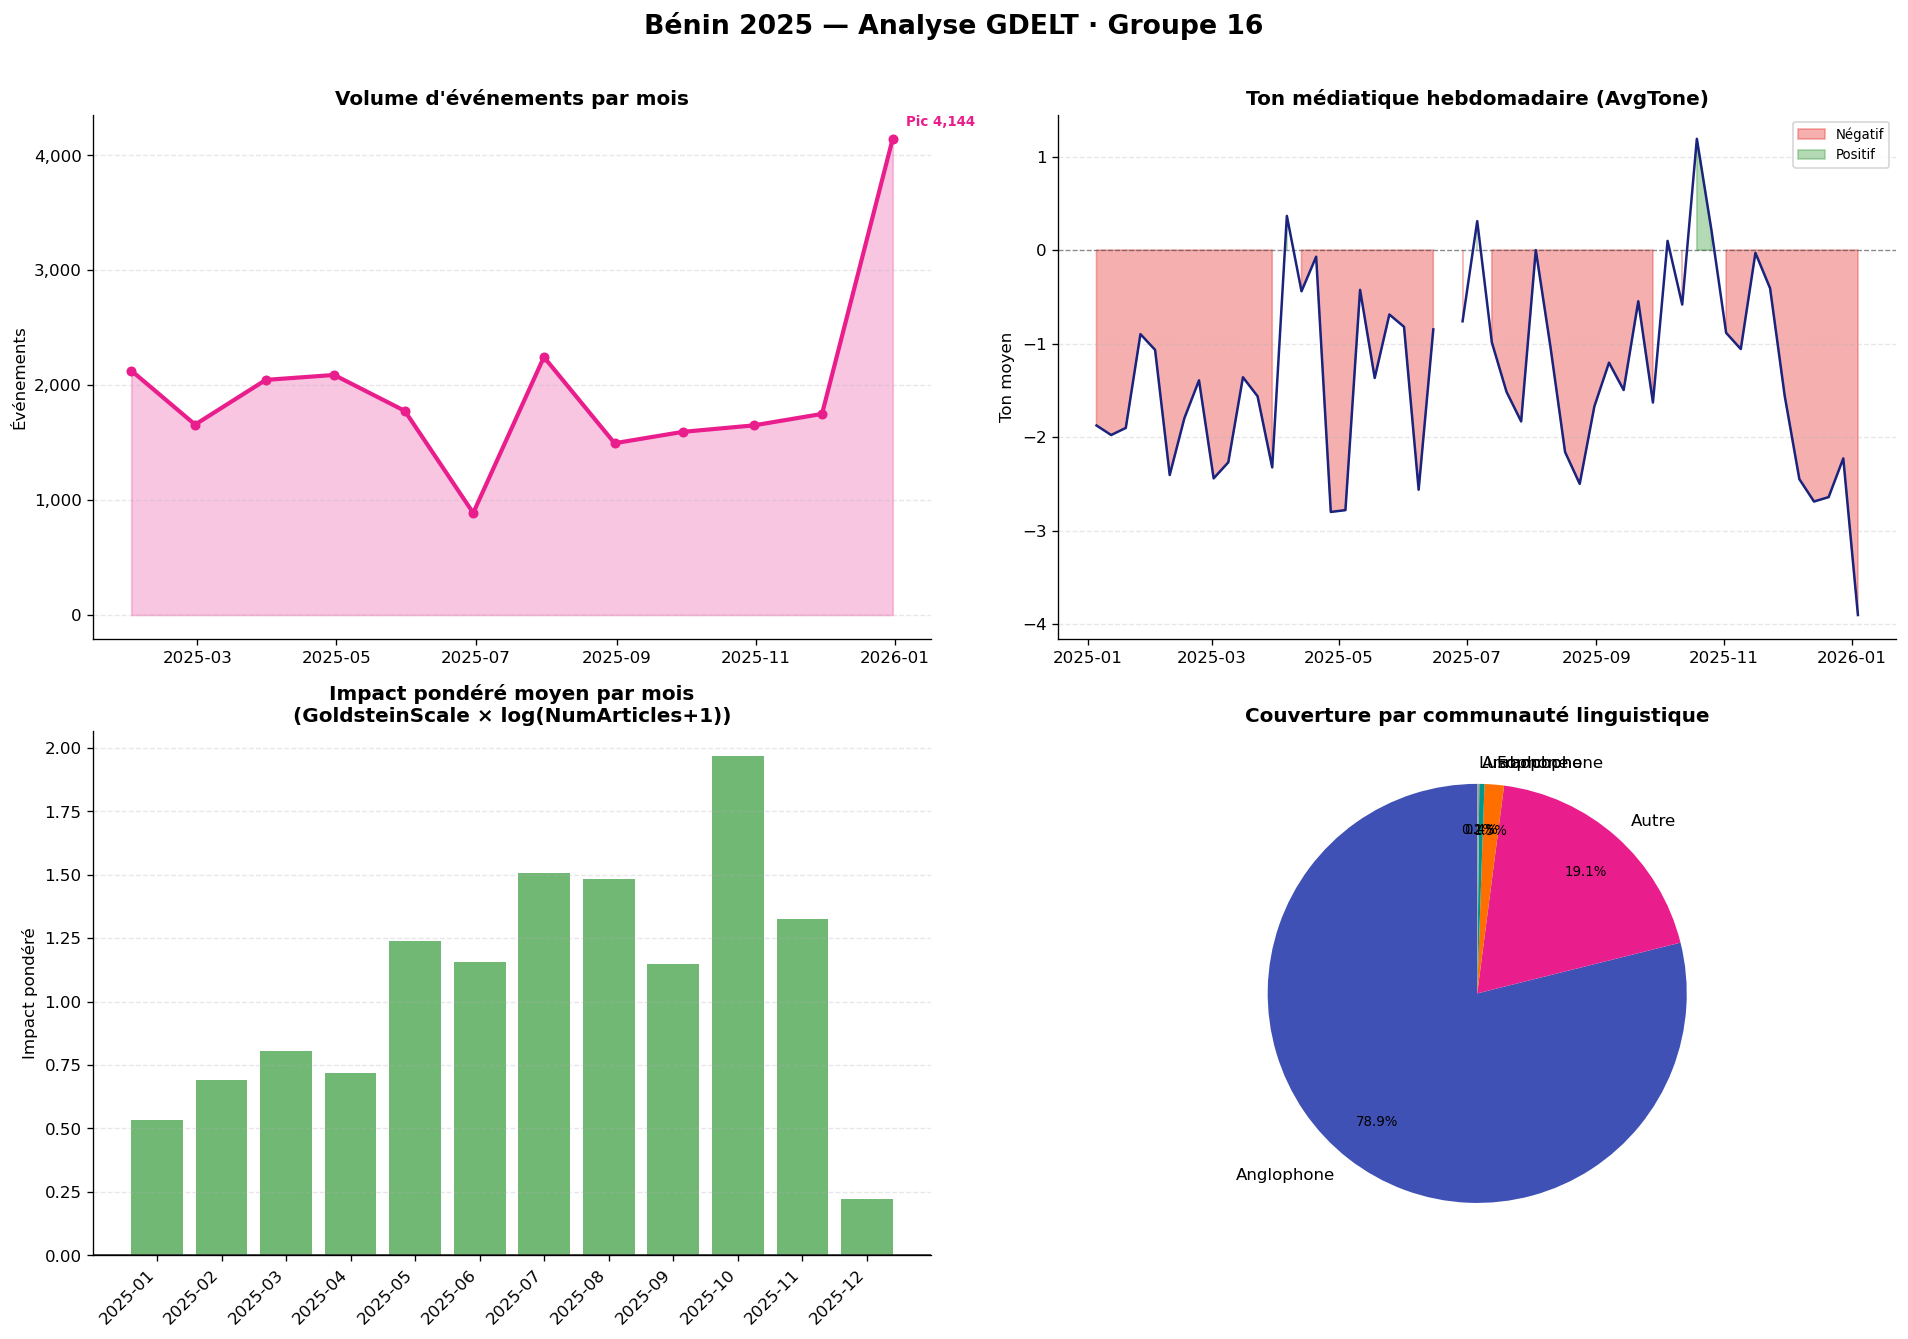

✅ Panel EDA sauvegardé : data/eda_panel_benin_2025.png


In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# ── Vérification préalable ──────────────────────────────────────
# ── CORRECTION : utiliser le bon dataframe ──────────────────────
df = df_raw.copy()

# Vérification
print(f"✅ {len(df):,} lignes chargées")
print(f"   Période : {df['SQLDATE'].min()} → {df['SQLDATE'].max()}")
# ── S'assurer que SQLDATE est bien en datetime ──────────────────
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], errors='coerce')
df = df.dropna(subset=['SQLDATE'])
df = df[df['SQLDATE'].dt.year == 2025]
print(f"   Après nettoyage : {len(df):,} lignes 2025")

# ── Dashboard 4 panels ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Bénin 2025 — Analyse GDELT · Groupe 16',
             fontsize=16, fontweight='bold', y=1.01)

# --- VIZ 1 : Volume mensuel ---
ax = axes[0, 0]
ev_mois = (df.set_index('SQLDATE')
             .resample('ME')
             .size()
             .reset_index())
ev_mois.columns = ['date', 'nb']  # ← nom uniforme 'date'

if len(ev_mois) > 0 and ev_mois['nb'].sum() > 0:
    ax.fill_between(ev_mois['date'], ev_mois['nb'], alpha=0.25, color='#E91E8C')
    ax.plot(ev_mois['date'], ev_mois['nb'],
            color='#E91E8C', lw=2.5, marker='o', ms=5)
    max_idx = ev_mois['nb'].idxmax()
    ax.annotate(f'Pic {ev_mois.loc[max_idx, "nb"]:,}',
                xy=(ev_mois.loc[max_idx, 'date'],   # ← 'date' pas 'SQLDATE'
                    ev_mois.loc[max_idx, 'nb']),
                xytext=(8, 8), textcoords='offset points',
                fontsize=8, color='#E91E8C', fontweight='bold')
ax.set_title('Volume d\'événements par mois', fontweight='bold')
ax.set_ylabel('Événements')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3, ls='--')
ax.spines[['top', 'right']].set_visible(False)

# --- VIZ 2 : Ton médiatique hebdomadaire ---
ax = axes[0, 1]
ton_hebdo = (df.set_index('SQLDATE')['AvgTone']
               .resample('W')
               .mean()
               .reset_index())
ton_hebdo.columns = ['date', 'AvgTone']

ax.axhline(0, color='#333', lw=0.8, ls='--', alpha=0.5)
ax.fill_between(ton_hebdo['date'], ton_hebdo['AvgTone'], 0,
                where=(ton_hebdo['AvgTone'] < 0),
                color='#E53935', alpha=0.4, label='Négatif')
ax.fill_between(ton_hebdo['date'], ton_hebdo['AvgTone'], 0,
                where=(ton_hebdo['AvgTone'] >= 0),
                color='#43A047', alpha=0.4, label='Positif')
ax.plot(ton_hebdo['date'], ton_hebdo['AvgTone'], color='#1A237E', lw=1.5)
ax.set_title('Ton médiatique hebdomadaire (AvgTone)', fontweight='bold')
ax.set_ylabel('Ton moyen')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3, ls='--')
ax.spines[['top', 'right']].set_visible(False)

# --- VIZ 3 : Impact pondéré mensuel ---
ax = axes[1, 0]

# Recréer impact_pondere si absent
if 'impact_pondere' not in df.columns:
    df['impact_pondere'] = df['GoldsteinScale'] * np.log1p(df['NumArticles'].fillna(0))

df['mois'] = df['SQLDATE'].dt.strftime('%Y-%m')
impact_mois = df.groupby('mois')['impact_pondere'].mean()
colors_impact = ['#E53935' if v < 0 else '#43A047' for v in impact_mois.values]
ax.bar(impact_mois.index, impact_mois.values, color=colors_impact, alpha=0.75)
ax.axhline(0, color='#333', lw=1)
ax.set_title('Impact pondéré moyen par mois\n(GoldsteinScale × log(NumArticles+1))',
             fontweight='bold')
ax.set_ylabel('Impact pondéré')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, ls='--')
ax.spines[['top', 'right']].set_visible(False)

# --- VIZ 4 : Couverture par communauté linguistique ---
ax = axes[1, 1]

# Recréer communaute_linguistique si absente
if 'communaute_linguistique' not in df.columns:
    def detect_langue(url):
        if pd.isna(url): return 'Autre'
        url = str(url).lower()
        if any(x in url for x in ['.fr', 'france', 'lemonde', 'rfi', 'bbc.fr']): return 'Francophone'
        if any(x in url for x in ['.ng', '.com', 'reuters', 'bbc', 'daily']): return 'Anglophone'
        if any(x in url for x in ['.pt', 'brasil']): return 'Lusophone'
        if any(x in url for x in ['.ar', 'arab', 'aljazeera']): return 'Arabophone'
        return 'Autre'
    df['communaute_linguistique'] = df['SOURCEURL'].apply(detect_langue)

comm = df['communaute_linguistique'].value_counts()
colors_comm = ['#3F51B5', '#E91E8C', '#FF6F00', '#009688', '#9E9E9E']
wedges, texts, autotexts = ax.pie(
    comm.values, labels=comm.index,
    colors=colors_comm[:len(comm)],
    autopct='%1.1f%%', startangle=90, pctdistance=0.78
)
for at in autotexts:
    at.set_fontsize(8)
ax.set_title('Couverture par communauté linguistique', fontweight='bold')

plt.tight_layout()
os.makedirs('data', exist_ok=True)
plt.savefig('data/eda_panel_benin_2025.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Panel EDA sauvegardé : data/eda_panel_benin_2025.png')

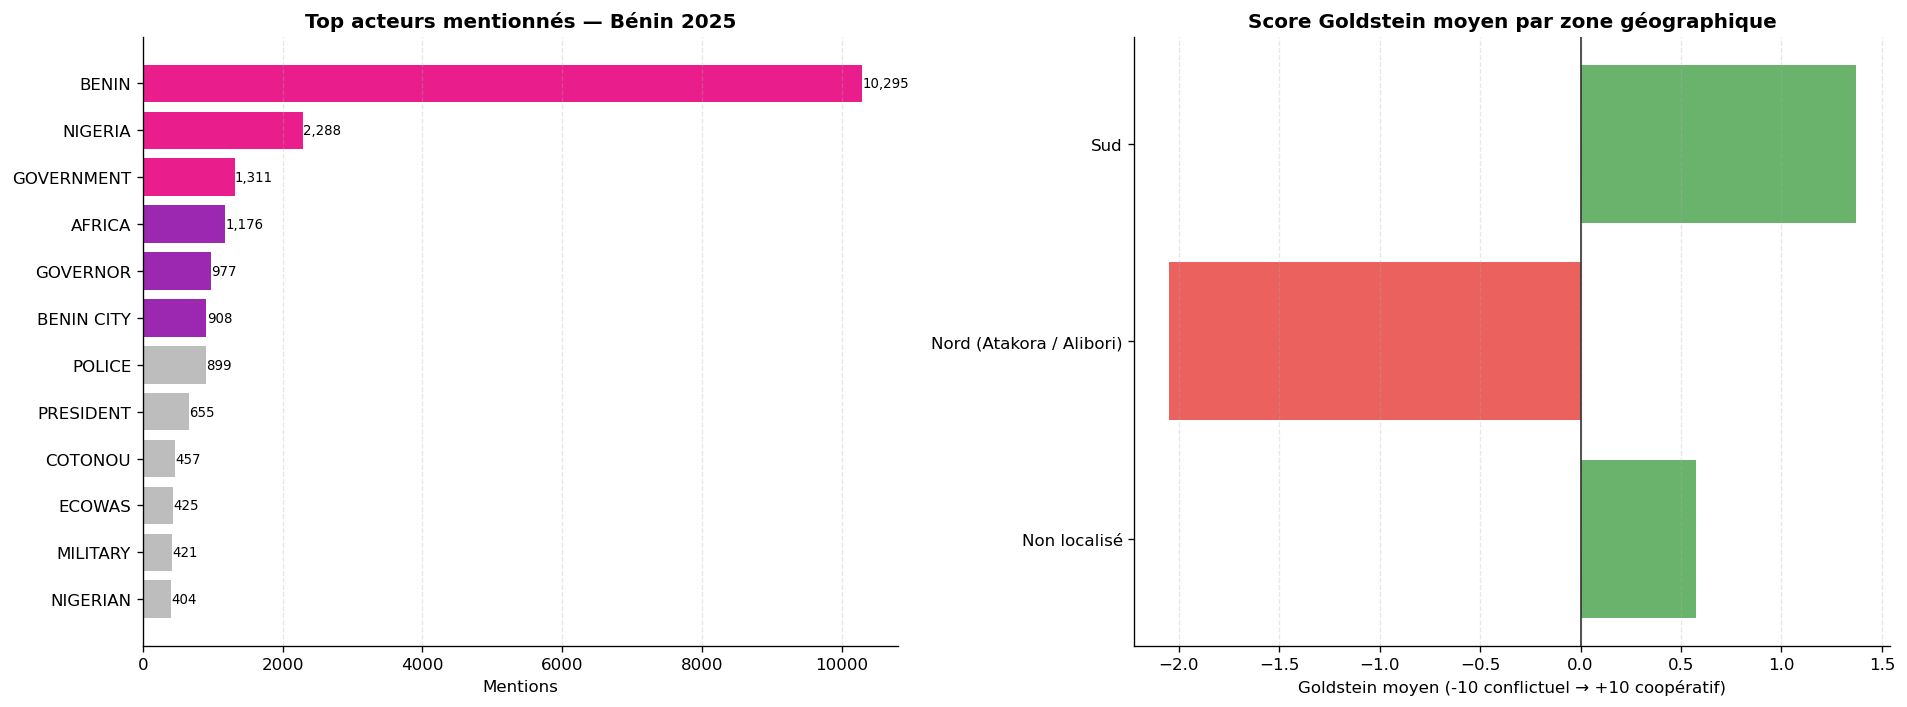

✅ Visualisation acteurs & zones sauvegardée


In [37]:
# --- VIZ 5 : Top 10 des acteurs + zones conflictuelles ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top acteurs
acteurs = pd.concat([
    df[df['Actor1Name'] != 'Non identifié']['Actor1Name'],
    df[df['Actor2Name'] != 'Non identifié']['Actor2Name']
], ignore_index=True).value_counts().head(12)

couleurs = ['#E91E8C' if i < 3 else '#9C27B0' if i < 6 else '#BDBDBD'
            for i in range(len(acteurs))]
ax1.barh(acteurs.index[::-1], acteurs.values[::-1], color=couleurs[::-1])
for i, (idx, val) in enumerate(zip(acteurs.index[::-1], acteurs.values[::-1])):
    ax1.text(val + 5, i, f'{val:,}', va='center', fontsize=8)
ax1.set_title('Top acteurs mentionnés — Bénin 2025', fontweight='bold')
ax1.set_xlabel('Mentions')
ax1.grid(axis='x', alpha=0.3, ls='--'); ax1.spines[['top', 'right']].set_visible(False)

# Goldstein moyen par zone
goldstein_zone = df.groupby('zone_geo').agg(
    goldstein=('GoldsteinScale', 'mean'),
    nb_ev=('SQLDATE', 'count'),
    impact=('impact_pondere', 'mean')
).reset_index()

colors_zone = ['#E53935' if v < 0 else '#43A047' for v in goldstein_zone['goldstein']]
ax2.barh(goldstein_zone['zone_geo'], goldstein_zone['goldstein'], color=colors_zone, alpha=0.8)
ax2.axvline(0, color='#333', lw=1)
ax2.set_title('Score Goldstein moyen par zone géographique', fontweight='bold')
ax2.set_xlabel('Goldstein moyen (-10 conflictuel → +10 coopératif)')
ax2.grid(axis='x', alpha=0.3, ls='--'); ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('data/eda_acteurs_zones.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Visualisation acteurs & zones sauvegardée')

---
## 📋 Résumé des décisions pipeline (V2)

| Décision | Statut | Justification |
|---|---|---|
| Filtre YEAR=2025 BigQuery + SQLDATE Python | ✅ Adoptée | Double sécurité sur la période |
| Ajout QuadClass + EventBaseCode | ✅ Adoptée | Colonnes critiques absentes de l'EDA initiale |
| Ajout Actor1/2Type1Code | ✅ Adoptée | Identifier 'qui agit' — essentiel chercheur/journaliste |
| Filtrage géo anti-Benin City | ✅ Adoptée | Biais confirmé EDA — risque de perte minime |
| NaN CountryCode conservés | ✅ Adoptée | Manquants informatifs |
| NaN TypeCode → 'Non identifié' | ✅ Adoptée | Décision unanime équipe |
| zone_geo (3 catégories avec 'Non localisé') | ✅ Adoptée | Reformulée suite réserves équipe |
| impact_pondere = Goldstein × log(NumArticles+1) | ✅ Adoptée | Combine stabilité + visibilité médiatique |
| communaute_linguistique | ✅ Adoptée | Comprendre couverture par communauté |
| Agrégation par événement réel | 🔄 Phase 2 | Complexité technique — NumArticles en proxy |
| Filtre score de confiance | 🔄 Phase 2 | Nécessite jointure table Mentions |

---
*Pipeline implémenté par ML Engineer #2 (Data Engineer) — validé par ML Engineer #1 (Chef de projet)*  
*Bénin Insights Challenge · Groupe 16 · iSHEERO × DataCamp Donates · 2025*

In [50]:
import os

# Chemin absolu vers ton dossier hackathon
DOSSIER = r"c:\Users\USER\Documents\Hackathon isheero"
os.makedirs(f"{DOSSIER}/data/processed", exist_ok=True)

# Export CSV principal
df_raw.to_csv(f"{DOSSIER}/data/processed/benin_2025_clean.csv", index=False)

# Export agrégat mensuel
agregat = df_raw.groupby(df_raw['SQLDATE'].dt.strftime('%Y-%m')).agg(
    nb_events   = ('SQLDATE', 'count'),
    goldstein   = ('GoldsteinScale', 'mean'),
    ton_moyen   = ('AvgTone', 'mean'),
    nb_articles = ('NumArticles', 'sum'),
).reset_index()
agregat.columns = ['mois','nb_events','goldstein','ton_moyen','nb_articles']
agregat.to_csv(f"{DOSSIER}/data/processed/benin_2025_agregat_mensuel.csv", index=False)

# Vérification
for f in ['benin_2025_clean.csv', 'benin_2025_agregat_mensuel.csv']:
    path = f"{DOSSIER}/data/processed/{f}"
    taille = os.path.getsize(path) / 1024
    print(f"✅ {f} — {taille:.1f} Ko")

✅ benin_2025_clean.csv — 4319.8 Ko
✅ benin_2025_agregat_mensuel.csv — 0.7 Ko
